In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ────────────────────────────────────────────────
# 1. Load the Pima Indians Diabetes dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'

names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
         'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, header=None, names=names)

# Feature: Glucose (usually the strongest single predictor)
X = df[['Glucose']].values   # shape (768, 1)

# Target: 1 = diabetes, 0 = no diabetes
y = df['Outcome'].values

# ────────────────────────────────────────────────
# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ────────────────────────────────────────────────
# 3. Train logistic regression (single feature)
model = LogisticRegression()
model.fit(X_train, y_train)

# ────────────────────────────────────────────────
# 4. Predictions & accuracy
# ────────────────────────────────────────────────
# Predictions on TEST set (this is what metrics need)
x_values = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_pred = model.predict(X_test)
y_prob_test = model.predict_proba(X_test)[:, 1]   # ← probabilities for the 154 test samples

# Evaluation metrics use y_test and y_prob_test (both have 154 samples)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# ROC curve – now both inputs have the same length (154)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
auc_score = roc_auc_score(y_test, y_prob_test)

# Plot ROC
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.show()
# ────────────────────────────────────────────────
# 6. Plot — same style as your Iris example

# Scatter: actual test points (0 = blue, 1 = orange)
plt.scatter(X_test, y_test)


# Sigmoid curve
plt.plot(x_values, y_prob)



plt.show()


Accuracy: 0.7077922077922078


NameError: name 'confusion_matrix' is not defined

In [47]:
# plt.scatter(X_test,y_test)

Accuracy (using only Glucose): 0.7078 (70.8%)

Confusion Matrix:
 [[85 15]
 [30 24]]

Classification Report:
               precision    recall  f1-score   support

           0      0.739     0.850     0.791       100
           1      0.615     0.444     0.516        54

    accuracy                          0.708       154
   macro avg      0.677     0.647     0.653       154
weighted avg      0.696     0.708     0.694       154



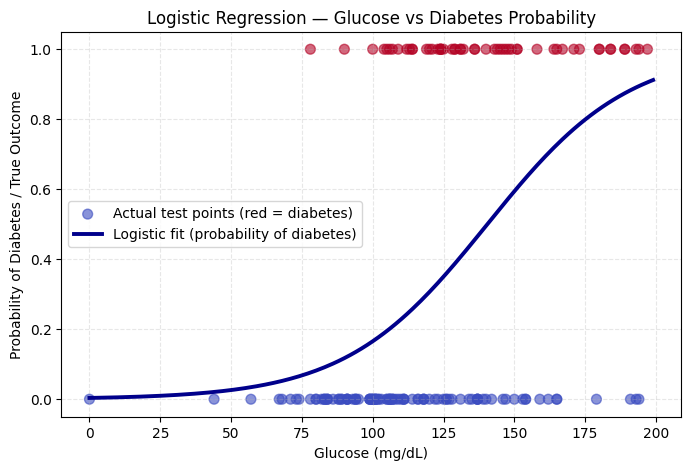

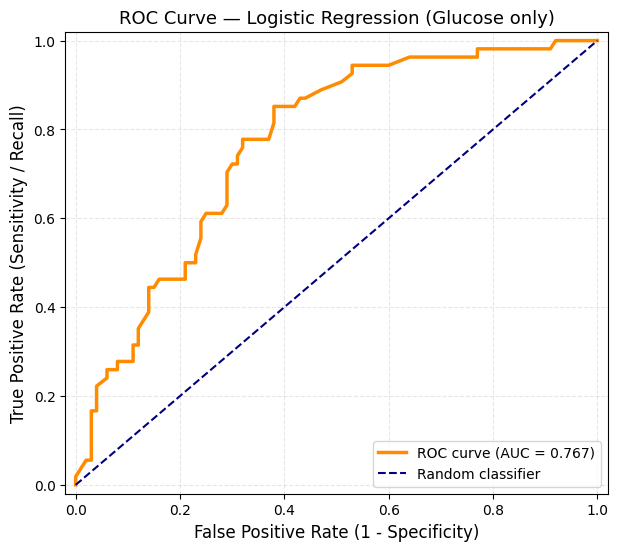

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ────────────────────────────────────────────────
# 1. Load the Pima Indians Diabetes dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
         'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, header=None, names=names)

# Feature: Glucose (single predictor)
X = df[['Glucose']].values   # shape (768, 1)
y = df['Outcome'].values     # 0 = no diabetes, 1 = diabetes

# ────────────────────────────────────────────────
# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ────────────────────────────────────────────────
# 3. Train logistic regression (single feature)
model = LogisticRegression()
model.fit(X_train, y_train)

# ────────────────────────────────────────────────
# 4. Predictions & evaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]   # probability of class 1 (diabetes)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (using only Glucose): {acc:.4f} ({acc*100:.1f}%)")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# ────────────────────────────────────────────────
# 5. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# ────────────────────────────────────────────────
# 6. Plot 1: Probability (sigmoid) curve — original plot
plt.figure(figsize=(8, 5))

# Scatter: actual test points
plt.scatter(X_test, y_test,
            c=y_test, cmap='coolwarm', alpha=0.6, s=50,
            label='Actual test points (red = diabetes)')

# Sigmoid curve over full range
x_values = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_prob_curve = model.predict_proba(x_values)[:, 1]

plt.plot(x_values, y_prob_curve, color='darkblue', linewidth=2.8,
         label='Logistic fit (probability of diabetes)')

plt.xlabel("Glucose (mg/dL)")
plt.ylabel("Probability of Diabetes / True Outcome")
plt.title("Logistic Regression — Glucose vs Diabetes Probability")
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.ylim(-0.05, 1.05)
plt.show()

# ────────────────────────────────────────────────
# 7. Plot 2: ROC Curve
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, color='darkorange', lw=2.5,
         label=f'ROC curve (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random classifier')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('ROC Curve — Logistic Regression (Glucose only)', fontsize=13)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='lower right')
plt.show()